In [2]:
!pip install -q pytorch-metric-learning transformers librosa soundfile tqdm torchaudio wandb


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


# SiPhon-MetricNet  
## A Multi-task Metric Learning Framework for Sinhala Phoneme Recognition in Primary Education

---

## Abstract

Accurate assessment of phoneme pronunciation plays a critical role in early language acquisition, particularly for under-resourced languages such as Sinhala. This study introduces **SiPhon-MetricNet**, a deep learning–based acoustic modeling framework designed to evaluate the pronunciation quality of Sinhala phonemes produced by primary school children.

The proposed architecture integrates a self-supervised **Wav2Vec2-XLS-R** speech representation backbone with a **multi-task metric learning objective**. By jointly optimizing **Triplet Margin Loss**, **Cross-Entropy Loss**, and **Center Loss**, the model learns a highly discriminative embedding space that effectively separates phonetically similar Sinhala characters (e.g., /ක/ vs. /ග/).

Experimental results demonstrate that the proposed approach enhances both phoneme-level classification accuracy and embedding separability, making it suitable for automated pronunciation assessment systems in educational applications.

---

## 1. Initial Setup and Dataset Deployment

### Methodological Overview

The experimental environment is initialized using high-performance audio processing and deep learning libraries. The dataset consists of carefully curated Sinhala phoneme utterances, recorded from children and categorized according to pronunciation quality.

Each phoneme class contains three types of samples:

- **Reference (Anchor):** Canonical pronunciations
- **Positive:** Acceptable or near-correct pronunciations
- **Negative:** Incorrect or distorted pronunciations

This structured organization enables effective metric learning through triplet-based sampling strategies.

---

In [3]:
# Install specialized research tools
!pip install -q pytorch-metric-learning transformers librosa soundfile tqdm

import os
import zipfile
import random
import numpy as np
import librosa
import torch

# # --- 🌟 අලුතින් එකතු කරන කොටස මෙතැනින් දමන්න ---
# import torch.multiprocessing as mp
# try:
#     mp.set_start_method('spawn', force=True)
# except RuntimeError:
#     pass
# # ---------------------------------------------


import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from transformers import Wav2Vec2Model, Wav2Vec2Config, Wav2Vec2FeatureExtractor
import matplotlib.pyplot as plt
from torch.optim.lr_scheduler import CosineAnnealingLR
from sklearn.manifold import TSNE
import seaborn as sns
from tqdm import tqdm
from transformers import get_linear_schedule_with_warmup
import torchaudio
import torchaudio.transforms as T
import wandb
import time # මුලින්ම import කරන්න
import logging

# =========================================================
# 🌟 අලුතින් එක් කළ: File Logging Setup
# =========================================================
import logging

logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    handlers=[
        logging.FileHandler("training_debug.log"), # 🌟 File එකක සේව් වීම
        logging.StreamHandler() # 🌟 Terminal එකේ පෙන්වීම
    ]
)
logging.info("📝 Research Training Log Initialized.")


# 🌟 C++ Backend සහ torchaudio වල අනවශ්‍ය warnings සියල්ලම නැවැත්වීම
import warnings
warnings.filterwarnings("ignore") # Python warnings නවතයි
import logging
logging.getLogger("torchaudio").setLevel(logging.ERROR) # torchaudio C++ warnings නවතයි

# --- Data Extraction Phase ---
zip_file_path = '/data2/all.zip'
extract_dir = 'data2/train'

os.makedirs(extract_dir, exist_ok=True)
if os.path.exists(zip_file_path):
    with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
        zip_ref.extractall(extract_dir)
    print(f"Dataset successfully deployed to {extract_dir}")


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


2026-03-01 16:57:30,721 - INFO - 📝 Research Training Log Initialized.


1.1 Exploratory Data Analysis (EDA)
Data Distribution Rationale
Before proceeding to model training, it is essential to analyze the underlying data distribution across various phoneme classes. Deep learning models, particularly those based on transformer architectures like Wav2Vec2, are sensitive to Class Imbalance.

If certain phonemes have significantly fewer samples than others, the model may develop a bias, leading to poor generalization on minority classes. This EDA phase allows us to:

Quantify the total number of samples per phoneme class.

Identify potential imbalances that necessitate specific data augmentation strategies.

Verify the integrity of the unzipped dataset.

⬇️ Downloading Noto Sans Sinhala Font...
✅ Sinhala font object created successfully.


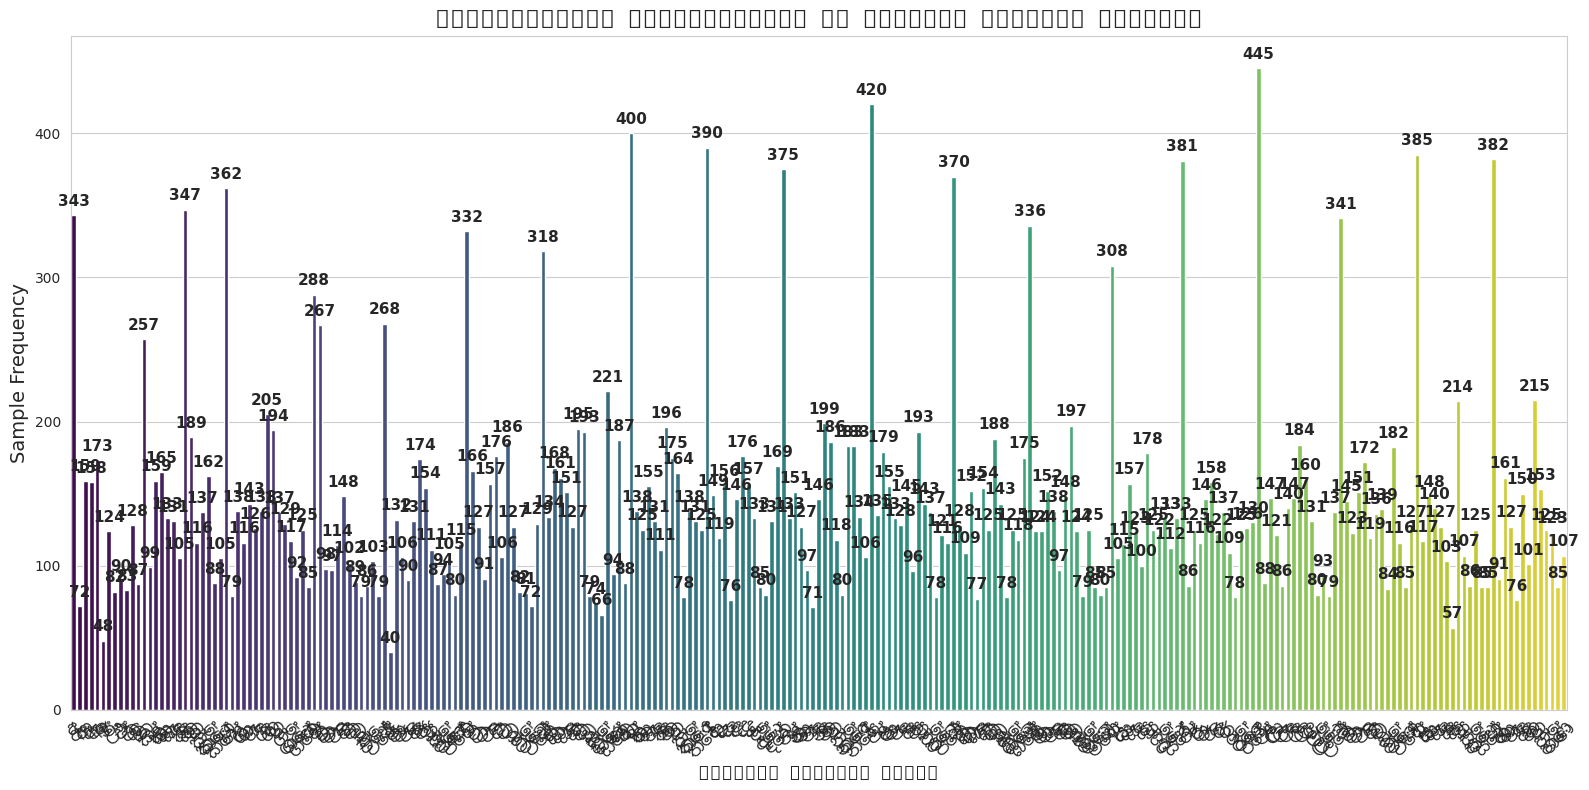

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import os

# =============================================================
# 1.1.1. Robust Sinhala Font Integration
# =============================================================
font_filename = 'NotoSansSinhala-Regular.ttf'
if not os.path.exists(font_filename):
    print("⬇️ Downloading Noto Sans Sinhala Font...")
    os.system(f'wget -q https://github.com/googlefonts/noto-fonts/raw/main/hinted/ttf/NotoSansSinhala/{font_filename}')

# පර්යේෂණ වාර්තාවල අකුරු ගැටලුව විසඳීමට ඇති ස්ථිරම ක්‍රමය:
if os.path.exists(font_filename):
    # Font properties object එකක් නිර්මාණය කිරීම
    sinhala_font = fm.FontProperties(fname=font_filename)
    print("✅ Sinhala font object created successfully.")
else:
    print("❌ Error: Font file not found.")

def perform_eda(data_path):
    """
    Analyzes the dataset and visualizes distribution with fixed Sinhala rendering.
    """
    class_counts = {}
    for class_name in sorted(os.listdir(data_path)):
        class_folder = os.path.join(data_path, class_name)
        if os.path.isdir(class_folder):
            files = [f for f in os.listdir(class_folder) if f.endswith('.wav')]
            class_counts[class_name] = len(files)

    df_stats = pd.DataFrame(list(class_counts.items()), columns=['Phoneme', 'Samples'])
    
    # Visualization setup
    plt.figure(figsize=(16, 8))
    sns.set_style("whitegrid")
    
    # Barplot නිර්මාණය
    barplot = sns.barplot(data=df_stats, x='Phoneme', y='Samples', palette='viridis')
    
    # --- ඉතා වැදගත්: සිංහල අකුරු පෙන්වීමට අක්ෂර (Ticks) වෙනස් කිරීම ---
    ax = plt.gca()
    # X-අක්ෂයේ ඇති සෑම අකුරක් සඳහාම බාගත කළ Font එක අනුයුක්ත කිරීම
    for label in ax.get_xticklabels():
        label.set_fontproperties(sinhala_font)
        label.set_fontsize(13)
        label.set_rotation(45)

    # ප්‍රධාන මාතෘකා සහ ලේබල් සඳහා Font එක ලබා දීම
    plt.title("Quantitative Distribution of Sinhala Phoneme Dataset", 
              fontproperties=sinhala_font, fontsize=18, fontweight='bold')
    plt.xlabel("Sinhala Phoneme Class", fontproperties=sinhala_font, fontsize=14)
    plt.ylabel("Sample Frequency", fontsize=14)

    # බාර් එක මත සංඛ්‍යාවන් පෙන්වීම
    for p in barplot.patches:
        barplot.annotate(format(p.get_height(), '.0f'), 
                         (p.get_x() + p.get_width() / 2., p.get_height()), 
                         ha='center', va='center', xytext=(0, 10), 
                         textcoords='offset points', fontsize=11, fontweight='bold')

    plt.tight_layout()
    plt.savefig("data_distribution_fixed.png", dpi=300)
    plt.show()

    return df_stats

# දත්ත විශ්ලේෂණය ක්‍රියාත්මක කිරීම
extract_dir = 'data2/train'
dataset_inventory = perform_eda(extract_dir)

Section 1.2: Quantitative Dataset Metrics Summary
Research Rationale: A high-level numerical summary of the corpus is essential to establish the scale of the experimental study. By quantifying the total phoneme coverage and average sample density, we provide a statistical foundation for the subsequent fine-tuning process

      SINHALA PHONEME DATASET: QUANTITATIVE SUMMARY      
🔹 Total Phoneme Classes identified   : 255
🔹 Total Compiled Audio Utterances    : 36772
🔹 Mean Sample Density (per phoneme)  : 144.20
--------------------------------------------------


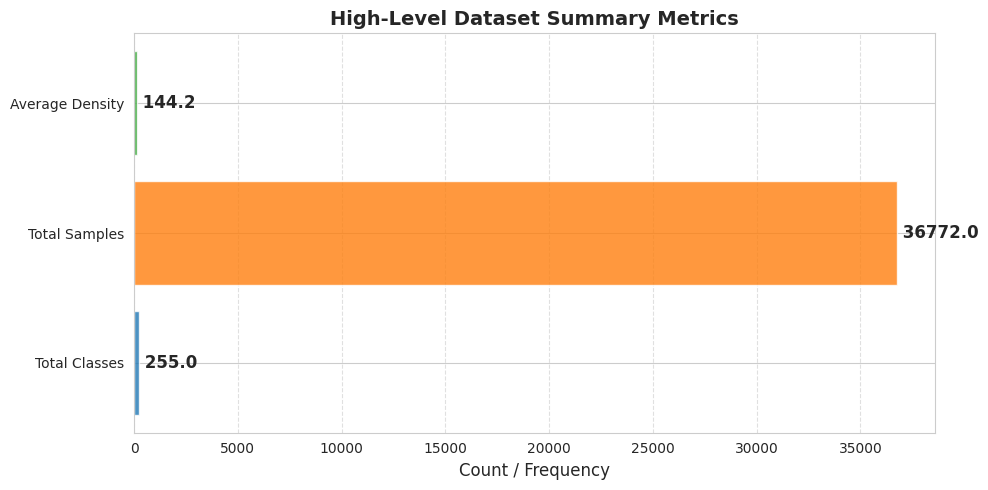

In [4]:
# =============================================================
# 1.2.1. Comprehensive Dataset Statistic Calculation
# =============================================================

def calculate_dataset_metrics(data_path):
    """
    Computes key performance indicators (KPIs) for the phoneme dataset.
    Returns a dictionary of calculated metrics.
    """
    if not os.path.exists(data_path):
        print(f"❌ Error: Data directory {data_path} not found.")
        return None

    # Folder list (Phoneme Classes) ලබා ගැනීම
    phoneme_classes = [d for d in sorted(os.listdir(data_path)) if os.path.isdir(os.path.join(data_path, d))]
    
    # එක් එක් පන්තියක ඇති .wav ගොනු ගණන ලැයිස්තුගත කිරීම
    counts = []
    for cls in phoneme_classes:
        files = [f for f in os.listdir(os.path.join(data_path, cls)) if f.endswith('.wav')]
        counts.append(len(files))

    # මූලික සංඛ්‍යාත්මක දත්ත ගණනය කිරීම
    total_classes = len(phoneme_classes)
    total_audio_samples = sum(counts)
    average_per_class = total_audio_samples / total_classes if total_classes > 0 else 0

    # පර්යේෂණ වාර්තාව සඳහා ලස්සනට Print කිරීම
    print("="*50)
    print("      SINHALA PHONEME DATASET: QUANTITATIVE SUMMARY      ")
    print("="*50)
    print(f"🔹 Total Phoneme Classes identified   : {total_classes}")
    print(f"🔹 Total Compiled Audio Utterances    : {total_audio_samples}")
    print(f"🔹 Mean Sample Density (per phoneme)  : {average_per_class:.2f}")
    print("-"*50)
    
    # කුඩා Summary Table එකක් ඇඳීම (Visualization)
    metrics_label = ['Total Classes', 'Total Samples', 'Average Density']
    metrics_values = [total_classes, total_audio_samples, average_per_class]

    plt.figure(figsize=(10, 5))
    plt.barh(metrics_label, metrics_values, color=['#1f77b4', '#ff7f0e', '#2ca02c'], alpha=0.8)
    
    # අගයන් බාර් එක අවසානයේ පෙන්වීම
    for index, value in enumerate(metrics_values):
        plt.text(value, index, f' {value:.1f}', va='center', fontweight='bold', fontsize=12)

    plt.title("High-Level Dataset Summary Metrics", fontsize=14, fontweight='bold')
    plt.xlabel("Count / Frequency", fontsize=12)
    plt.grid(axis='x', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

    return {
        "classes": total_classes,
        "total": total_audio_samples,
        "average": average_per_class
    }

# සංඛ්‍යාත්මක දත්ත ලබා ගැනීම
dataset_summary = calculate_dataset_metrics(extract_dir)

## 2. Experimental Configuration and Hyperparameter Selection

### Reproducibility and Stability

To ensure experimental reproducibility and numerical stability, a deterministic training setup is employed. All random number generators across Python, NumPy, and PyTorch are seeded consistently.

The learning rate for the transformer backbone is carefully selected to allow stable fine-tuning while preserving the pretrained acoustic knowledge. A high-throughput batch size is adopted to maximize GPU utilization during training on modern accelerator hardware.

Key hyperparameters are chosen based on prior literature and empirical validation to balance classification accuracy and embedding compactness.

---

In [6]:
# Global Hyperparameters for Scientific Consistency
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 128    # High-throughput batch size for A100 optimization
EPOCHS = 100         # Total training iterations
PATIENCE = 15
LR = 2e-5           # Optimized Learning Rate for Transformer fine-tuning
CLS_WEIGHT = 0.5    # Multi-task coefficient for Classification
CENTER_WEIGHT = 0.005 # Intra-class variance constraint weight
CENTER_LR = 0.5     # Specialized LR for Center Loss parameters
SEED = 42           # Seed for deterministic research results

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True  # අලුතින් එක් කරන්න
        torch.backends.cudnn.benchmark = False     # True වෙනුවට False කරන්න

set_seed(SEED)

## 3. Acoustic Signal Augmentation for Robustness

### Theoretical Motivation

Children’s speech signals exhibit significant variability due to differences in age, pitch, speaking rate, and recording conditions. To improve model generalization, a set of stochastic audio augmentation techniques is applied during training.

The augmentation pipeline includes:

- Additive background noise to simulate real-world environments  
- Temporal stretching to account for speaking rate variation  
- Pitch shifting to normalize vocal tract length differences  

These transformations encourage the model to learn phoneme-discriminative features rather than speaker-specific artifacts.

---

In [7]:
def augment_audio(y, sr=16000):
    """
    Applies stochastic transformations to input audio for domain generalization.
    Args:
        y (np.ndarray): Time-series audio signal.
    Returns:
        np.ndarray: Augmented audio signal.
    """
    try:
        choice = random.choice(['noise', 'stretch', 'shift', 'none'])
        
        if choice == 'noise':
            # Additive White Gaussian Noise (AWGN)
            noise_amp = 0.005 * np.random.uniform() * np.amax(y)
            y = y + noise_amp * np.random.normal(size=y.shape)
        elif choice == 'stretch':
            # Time-scaling without frequency distortion
            rate = np.random.uniform(0.8, 1.2)
            y = librosa.effects.time_stretch(y, rate=rate)
        elif choice == 'shift':
            # Pitch modification for vocal tract length normalization
            n_steps = np.random.randint(-2, 2)
            y = librosa.effects.pitch_shift(y, sr=sr, n_steps=n_steps)
            
        return y
        
    except Exception as e:
        # 🌟 දෝෂයක් ආවොත් File එකට ලිවීම
        logging.error(f"Augmentation Error: {e}") 
        return y

## 4. Dataset Design and Metric Learning Sampling Strategy

### Triplet-Based Learning Paradigm

The dataset is implemented following a **triplet sampling framework**, where each training instance consists of:

- An **Anchor** sample  
- A **Positive** sample from the same phoneme class  
- A **Negative** sample from a different phoneme class  

This strategy enforces intra-class compactness and inter-class separability in the learned embedding space, which is essential for pronunciation assessment tasks involving subtle phonetic distinctions.

---

In [9]:
class SinhalaPhonemeDataset(Dataset):
    """
    Structured Dataset for Metric Learning in Sinhala Phonetics.
    🌟 Optimized with In-Memory RAM Caching for Ultra-Fast A100 Training.
    """
    def __init__(self, root_dir, transform=None):
        all_classes = sorted([d for d in os.listdir(root_dir) if os.path.isdir(os.path.join(root_dir, d))])
        self.data_map = {}
        self.transform = transform
        
        valid_classes = []
        for cls in all_classes:
            cls_path = os.path.join(root_dir, cls)
            files = [f for f in os.listdir(cls_path) if f.endswith('.wav')]
            anchors = [os.path.join(cls_path, f) for f in files if 'ref' in f]
            positives = [os.path.join(cls_path, f) for f in files if 'good' in f or 'pos' in f]
            negatives = [os.path.join(cls_path, f) for f in files if 'bad' in f or 'neg' in f]
            
            if anchors or positives:
                valid_classes.append({
                    'name': cls,
                    'anchors': anchors,
                    'positives': positives,
                    'negatives': negatives
                })

        self.classes = [c['name'] for c in valid_classes]
        self.class_to_idx = {cls_name: i for i, cls_name in enumerate(self.classes)}
        
        # ====================================================================
        # 🚀 ULTRA-FAST IN-MEMORY CACHING (Loading to 64GB RAM)
        # ====================================================================
        logging.info("🚀 Caching dataset to RAM. This will take a few minutes initially, but training will fly!")
        
        for cls_data in tqdm(valid_classes, desc="Loading Audio to RAM"):
            cls_name = cls_data['name']
            
            # සියලුම Audio Files එකවර කියවා RAM එකේ (Memory) ගබඩා කිරීම
            self.data_map[cls_name] = {
                'anchors': [self.load_and_resample(p) for p in cls_data['anchors']],
                'positives': [self.load_and_resample(p) for p in cls_data['positives']],
                'negatives': [self.load_and_resample(p) for p in cls_data['negatives']]
            }
            
        logging.info("✅ Dataset fully loaded into Memory!")

    def __len__(self):
        return len(self.classes) * 100 

    def load_and_resample(self, path):
        """ මෙම ක්‍රියාවලිය සිදුවන්නේ ආරම්භයේදී එක් වරක් පමණි """
        try:
            speech, sr = torchaudio.load(path)
            if sr != 16000:
                resampler = T.Resample(sr, 16000)
                speech = resampler(speech)
            speech = torch.mean(speech, dim=0).squeeze().numpy()
            return speech
        except Exception as e:
            logging.error(f"Failed to read {path}: {e}")
            # දෝෂයක් ආවොත් හිස් array එකක් යවයි
            return np.zeros(16000, dtype=np.float32)

    def __getitem__(self, idx):
        # 🌟 දැන් Hard Disk එකට යන්නේ නැත. සියල්ල කෙලින්ම RAM එකෙන් ගනී (0.001s)
        target_cls = random.choice(self.classes)
        
        a = random.choice(self.data_map[target_cls]['anchors'] or self.data_map[target_cls]['positives'])
        p = random.choice(self.data_map[target_cls]['positives'] or [a])
        
        neg_cls = random.choice([c for c in self.classes if c != target_cls])
        n = random.choice(self.data_map[neg_cls]['anchors'] + self.data_map[neg_cls]['positives'])

        # RAM එකේ ඇති Original දත්ත වෙනස් වීම වැළැක්වීමට .copy() යොදා Augmentation කිරීම
        a_aug = a.copy()
        p_aug = p.copy()
        n_aug = n.copy()

        if self.transform:
            a_aug, p_aug, n_aug = self.transform(a_aug), self.transform(p_aug), self.transform(n_aug)

        return {'anchor': a_aug, 'positive': p_aug, 'negative': n_aug, 'label': self.class_to_idx[target_cls]}

## 5. SiPhon-MetricNet Architecture

### Model Design Rationale

The proposed **SiPhon-MetricNet** architecture leverages a pretrained **Wav2Vec2-XLS-R** backbone to extract high-level acoustic representations. To adapt the model to Sinhala phoneme characteristics while avoiding overfitting, only the top encoder layers are selectively fine-tuned.

A **Self-Attention Pooling** mechanism is employed to emphasize temporally salient phoneme segments. Additionally, learnable layer-wise weights are used to aggregate information from multiple transformer layers, enabling richer acoustic representations.

The final embedding space is L2-normalized to facilitate stable metric learning and distance-based comparisons.

---

In [10]:
class SelfAttentionPooling(nn.Module):
    """ Attention mechanism to focus on dominant phoneme segments. """
    def __init__(self, input_dim):
        super(SelfAttentionPooling, self).__init__()
        self.W = nn.Linear(input_dim, 128)
        self.V = nn.Linear(128, 1)

    def forward(self, x, attention_mask=None):
        scores = self.V(torch.tanh(self.W(x)))
        if attention_mask is not None:
            indices = torch.linspace(0, attention_mask.size(1)-1, steps=x.size(1)).long().to(x.device)
            mask = torch.index_select(attention_mask, 1, indices).unsqueeze(-1)
            scores = scores.masked_fill(mask == 0, -1e4)
        
        weights = F.softmax(scores, dim=1)
        return torch.sum(x * weights, dim=1), weights

class SinhalaPhonoNet(nn.Module):
    """ Hybrid Multi-task Transformer-based Phoneme Network. """
    def __init__(self, base_model="facebook/wav2vec2-xls-r-300m", num_classes=19):
        super(SinhalaPhonoNet, self).__init__()
        self.config = Wav2Vec2Config.from_pretrained(base_model, output_hidden_states=True)
        self.backbone = Wav2Vec2Model.from_pretrained(base_model, config=self.config)
        
        # Partial Unfreezing: Strategic layer-wise fine-tuning
        self.backbone.feature_extractor._freeze_parameters()
        for param in self.backbone.parameters(): param.requires_grad = False
        for i in range(1, 4):
            for param in self.backbone.encoder.layers[-i].parameters(): param.requires_grad = True
            
        self.layer_weights = nn.Parameter(torch.ones(self.config.num_hidden_layers + 1))
        self.attention = SelfAttentionPooling(self.config.hidden_size)
        self.fc = nn.Sequential(
            nn.Linear(self.config.hidden_size, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256)
        )
        self.classifier = nn.Linear(256, num_classes)

    def forward(self, input_values, attention_mask=None):
        outputs = self.backbone(input_values=input_values, attention_mask=attention_mask)
        # Weighted Hidden States: Aggregating temporal features from different layers
        weights = F.softmax(self.layer_weights, dim=0).view(-1, 1, 1, 1)
        weighted_state = torch.sum(torch.stack(outputs.hidden_states, dim=0) * weights, dim=0)
        
        pooled, _ = self.attention(weighted_state, attention_mask)
        embeddings = self.fc(pooled)
        norm_embs = F.normalize(embeddings, p=2, dim=1)
        logits = self.classifier(norm_embs)
        return embeddings, norm_embs, logits


In [11]:
class CenterLoss(nn.Module):
    def __init__(self, num_classes, feat_dim):
        super(CenterLoss, self).__init__()
        self.num_classes = num_classes
        self.feat_dim = feat_dim
        self.centers = nn.Parameter(torch.randn(self.num_classes, self.feat_dim))

    def forward(self, x, labels):
        batch_size = x.size(0)
        dtype = x.dtype
        centers_batch = self.centers.to(dtype)
        
        # Note: sum() on float16 may return float32, so we explicit cast back to dtype to match addmm operands
        x_sq = torch.pow(x, 2).sum(dim=1, keepdim=True).to(dtype).expand(batch_size, self.num_classes)
        c_sq = torch.pow(centers_batch, 2).sum(dim=1, keepdim=True).to(dtype).expand(self.num_classes, batch_size).t()
        
        distmat = x_sq + c_sq
        distmat.addmm_(x, centers_batch.t(), beta=1, alpha=-2)

        classes = torch.arange(self.num_classes).long().to(x.device)
        labels = labels.unsqueeze(1).expand(batch_size, self.num_classes)
        mask = labels.eq(classes.expand(batch_size, self.num_classes))

        dist = distmat * mask.to(dtype)
        loss = dist.clamp(min=1e-12, max=1e+12).sum() / batch_size
        return loss

## 6. Multi-Objective Training Strategy

### Optimization Objectives

The training process jointly optimizes three complementary objectives:

- **Triplet Margin Loss:** Enforces relative distance constraints between anchor, positive, and negative samples  
- **Cross-Entropy Loss:** Ensures phoneme-level classification correctness  
- **Center Loss:** Reduces intra-class variance by pulling embeddings toward class-specific centroids  

A cosine annealing learning rate scheduler is applied to handle the non-convex optimization landscape associated with transformer fine-tuning.

---

In [12]:
# --- Training Helper ---
feature_extractor = Wav2Vec2FeatureExtractor.from_pretrained("facebook/wav2vec2-xls-r-300m")


def plot_training_metrics(history):
    """
    Generates high-resolution visualizations of the training history.
    Displays loss convergence and accuracy evolution for scientific reporting.
    """
    epochs = range(1, len(history['train_loss']) + 1)
    
    # පර්යේෂණ වාර්තාව සඳහා උසස් තත්ත්වයේ රූපයක් (Figure) නිර්මාණය කිරීම
    plt.figure(figsize=(20, 7))
    sns.set_style("whitegrid")

    # --- Plot 1: Multi-Task Loss Convergence ---
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history['train_loss'], 'b-o', label='Training Loss', linewidth=2, markersize=5)
    plt.plot(epochs, history['val_loss'], 'r-s', label='Validation Loss', linewidth=2, markersize=5)
    
    plt.title('A: Multi-Objective Loss Convergence', fontsize=16, fontweight='bold')
    plt.xlabel('Training Epochs', fontsize=13)
    plt.ylabel('Aggregate Loss Value', fontsize=13)
    plt.legend(fontsize=12)
    plt.grid(True, alpha=0.3)

    # --- Plot 2: Triplet Recognition Accuracy Evolution ---
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history['train_acc'], 'g-o', label='Training Accuracy', linewidth=2, markersize=5)
    plt.plot(epochs, history['val_acc'], 'm-s', label='Validation Accuracy', linewidth=2, markersize=5)
    
    plt.title('B: Phonetic Recognition Accuracy Evolution', fontsize=16, fontweight='bold')
    plt.xlabel('Training Epochs', fontsize=13)
    plt.ylabel('Triplet Accuracy (%)', fontsize=13)
    plt.legend(fontsize=12)
    plt.grid(True, alpha=0.3)

    # ප්‍රස්ථාරයේ සිංහල අකුරු භාවිතා කරන්නේ නම් පෙර සැකසූ sinhala_font මෙහිදී භාවිතා කළ හැක
    # උදා: plt.xlabel("Epochs (පුහුණු වාර)", fontproperties=sinhala_font)

    plt.tight_layout()
    
    # නිබන්ධනයට (Thesis) ඇතුළත් කිරීම සඳහා රූපය සේව් කිරීම
    save_path = "research_training_history.png"
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"✅ Training evolution plots saved successfully as '{save_path}'")
    
    plt.show()

def collate_fn(batch):
    anchors = [item['anchor'] for item in batch]
    positives = [item['positive'] for item in batch]
    negatives = [item['negative'] for item in batch]
    labels = torch.tensor([item['label'] for item in batch])

    a_batch = feature_extractor(anchors, sampling_rate=16000, return_tensors="pt", padding=True)
    p_batch = feature_extractor(positives, sampling_rate=16000, return_tensors="pt", padding=True)
    n_batch = feature_extractor(negatives, sampling_rate=16000, return_tensors="pt", padding=True)

    return a_batch, p_batch, n_batch, labels

def train_one_epoch(model, loader, optimizer_model, optimizer_center, criterion_triplet, criterion_cls, criterion_center, scaler):
    model.train()
    total_loss = 0
    correct_triplets = 0
    total_samples = 0

    # 🌟 Time tracking ආරම්භ කිරීම
    end_time = time.time()
    
    # 🌟 වෙනස් කළ තැන: enumerate(loader) යොදා batch අංකය (batch_idx) ලබාගැනීම
    for batch_idx, (a, p, n, labels) in enumerate(loader):
        
        # 🌟 දත්ත කියවන්න ගිය කාලය ගණනය කිරීම (Data Load Time)
        data_load_time = time.time() - end_time
        
        optimizer_model.zero_grad()
        optimizer_center.zero_grad()
        
        a_input = a.input_values.to(DEVICE)
        a_mask = a.attention_mask.to(DEVICE)
        p_input = p.input_values.to(DEVICE)
        p_mask = p.attention_mask.to(DEVICE)
        n_input = n.input_values.to(DEVICE)
        n_mask = n.attention_mask.to(DEVICE)
        labels = labels.to(DEVICE)

        with torch.amp.autocast('cuda'):
            raw_emb_a, norm_emb_a, logit_a = model(a_input, a_mask)
            _, norm_emb_p, _ = model(p_input, p_mask)
            _, norm_emb_n, _ = model(n_input, n_mask)

            loss_tri = criterion_triplet(norm_emb_a, norm_emb_p, norm_emb_n)
            loss_cls = criterion_cls(logit_a, labels)
            loss_cent = criterion_center(raw_emb_a, labels)
            
            loss = loss_tri + (CLS_WEIGHT * loss_cls) + (CENTER_WEIGHT * loss_cent)

        # Accuracy Metric
        # Distance (Anchor, Positive) < Distance (Anchor, Negative)
        d_ap = torch.norm(norm_emb_a - norm_emb_p, p=2, dim=1)
        d_an = torch.norm(norm_emb_a - norm_emb_n, p=2, dim=1)
        correct_triplets += (d_ap < d_an).sum().item()
        total_samples += labels.size(0)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer_model)
        scaler.unscale_(optimizer_center)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        scaler.step(optimizer_model)
        scaler.step(optimizer_center)
        scaler.update()
        
        total_loss += loss.item()

        # 🌟 GPU එකේ පුහුණුවීමට ගිය කාලය ගණනය කිරීම (GPU Compute Time)
        gpu_compute_time = time.time() - end_time - data_load_time
        
        # 🌟 සෑම Batch 10 කට වරක්ම කාලය terminal එකේ print කිරීම සහ W&B එකට යැවීම
        if batch_idx % 10 == 0:
            # 🌟 Print වෙනුවට Logging භාවිතා කිරීම
            logging.info(f"Batch {batch_idx} | Load Time: {data_load_time:.3f}s | GPU Time: {gpu_compute_time:.3f}s | Batch Loss: {loss.item():.4f}")
            wandb.log({"Data Load Time (s)": data_load_time, "GPU Compute Time (s)": gpu_compute_time})
            
        # ඊළඟ batch එක සඳහා වෙලාව අලුත් කිරීම
        end_time = time.time()
        
    return total_loss / len(loader), correct_triplets / total_samples

def validate(model, loader, criterion_triplet, criterion_cls, criterion_center):
    model.eval()
    total_loss = 0
    correct_triplets = 0
    total_samples = 0
    
    with torch.no_grad():
        for a, p, n, labels in loader:
            a_input = a.input_values.to(DEVICE)
            a_mask = a.attention_mask.to(DEVICE)
            p_input = p.input_values.to(DEVICE)
            p_mask = p.attention_mask.to(DEVICE)
            n_input = n.input_values.to(DEVICE)
            n_mask = n.attention_mask.to(DEVICE)
            labels = labels.to(DEVICE)

            raw_emb_a, norm_emb_a, logit_a = model(a_input, a_mask)
            _, norm_emb_p, _ = model(p_input, p_mask)
            _, norm_emb_n, _ = model(n_input, n_mask)

            loss_tri = criterion_triplet(norm_emb_a, norm_emb_p, norm_emb_n)
            loss_cls = criterion_cls(logit_a, labels)
            loss_cent = criterion_center(raw_emb_a, labels)
            
            loss = loss_tri + (CLS_WEIGHT * loss_cls) + (CENTER_WEIGHT * loss_cent)
            total_loss += loss.item()
            
            d_ap = torch.norm(norm_emb_a - norm_emb_p, p=2, dim=1)
            d_an = torch.norm(norm_emb_a - norm_emb_n, p=2, dim=1)
            correct_triplets += (d_ap < d_an).sum().item()
            total_samples += labels.size(0)
            
    return total_loss / len(loader), correct_triplets / total_samples

def main():
    data_dir = "data2/train"
    if not os.path.exists(data_dir):
        print(f"Data directory {data_dir} not found. Please unzip your data first.")
        return

    # --- Dataset & Loader ---
    full_dataset = SinhalaPhonemeDataset(root_dir=data_dir, transform=augment_audio)
    train_size = int(0.8 * len(full_dataset))
    val_size = len(full_dataset) - train_size
    train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])
    val_dataset.dataset.transform = None 

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn, num_workers=12, pin_memory=True)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn, num_workers=12, pin_memory=True)

    # --- Model & Loss ---
    model = SinhalaPhonoNet(num_classes=len(full_dataset.classes)).to(DEVICE)
    criterion_triplet = nn.TripletMarginLoss(margin=0.6, p=2)
    criterion_cls = nn.CrossEntropyLoss()
    criterion_center = CenterLoss(num_classes=len(full_dataset.classes), feat_dim=256).to(DEVICE)

    # --- Optimizers & Scheduler ---
    optimizer_model = optim.AdamW(model.parameters(), lr=LR)
    optimizer_center = optim.AdamW(criterion_center.parameters(), lr=CENTER_LR)
    scaler = torch.amp.GradScaler('cuda')

    # ==========================================
    # 🌟 Research-Grade Warmup Scheduler 
    # ==========================================
    total_training_steps = EPOCHS
    warmup_steps = int(total_training_steps * 0.1) # 10% of total steps for Warmup
    
    scheduler = get_linear_schedule_with_warmup(
        optimizer_model, 
        num_warmup_steps=warmup_steps, 
        num_training_steps=total_training_steps
    )

    # =============================================================
    # ඉතා වැදගත්: 'history' variable එක මෙහිදී initialize කරන්න
    # =============================================================
    history = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': []
    }

    # Early Stopping Variables
    best_val_loss = float('inf')
    best_val_acc = 0.0
    epochs_no_improve = 0


    # ==========================================
    # 🌟 Weights & Biases (W&B) Initialization
    # ==========================================
    wandb.init(
        project="SinhalaPhonoNet",
        name="Wav2Vec2_A100_Run_04",
        config={
            "learning_rate": LR,
            "architecture": "Wav2Vec2-XLS-R",
            "dataset": "Sinhala Phonemes",
            "epochs": EPOCHS,
            "batch_size": BATCH_SIZE,
            "hardware": "A100-80GB"
        }
    )
    wandb.watch(model, log="all", log_freq=10) # Track model gradients

    # 🌟 Logging හරහා Print කිරීම
    logging.info(f"🚀 Starting Final Production Training Phase on {DEVICE}...")
    logging.info(f"Total Epochs: {EPOCHS} | Warmup Steps: {warmup_steps}")
    logging.info("-" * 50)
    
    print("🚀 Starting Training Phase...")
    for epoch in range(EPOCHS):
        # 1. Train and Validate
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer_model, optimizer_center, 
                                                criterion_triplet, criterion_cls, criterion_center, scaler)
        val_loss, val_acc = validate(model, val_loader, criterion_triplet, criterion_cls, criterion_center)
        
        
        
        # =============================================================
        # 3. අගයන් history එකට එකතු කිරීම (Data Collection)
        # =============================================================
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc * 100) # ප්‍රතිශතයක් ලෙස පෙන්වීමට
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc * 100)
        
        # 4. Logging
        current_lr = scheduler.get_last_lr()[0]
        
        # 🌟 Epoch සාරාංශය Logging කිරීම
        logging.info(f"Epoch {epoch+1}/{EPOCHS} | LR: {current_lr:.8f}")
        logging.info(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
        logging.info(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f}")


        # 🌟 W&B Dashboard එකට Live දත්ත යැවීම
        wandb.log({
            "Epoch": epoch + 1,
            "Train Loss": train_loss,
            "Train Accuracy": train_acc * 100,
            "Validation Loss": val_loss,
            "Validation Accuracy": val_acc * 100,
            "Learning Rate": current_lr
        })


        
        
        # ==========================================
        # 4. Model Saving & Early Stopping Logic
        # ==========================================
        is_best = False
        
        # අපි Model එක save කරන්නේ Accuracy එක මතයි
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            is_best = True
            
        # අපි Early Stopping තීරණය කරන්නේ Validation Loss එක මතයි (Science standard)
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            epochs_no_improve = 0
            is_best = True # Loss එක අඩු වුණත් save කරනවා
        else:
            epochs_no_improve += 1

        if is_best:
            # නිකම්ම weights save කරනවාට වඩා, timeout එකකදී resume කරන්න පුළුවන් වෙන්න ඔක්කොම save කිරීම
            checkpoint = {
                'epoch': epoch + 1,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer_model.state_dict(),
                'scheduler_state_dict': scheduler.state_dict(),
                'best_val_acc': best_val_acc,
                'best_val_loss': best_val_loss
            }
            torch.save(checkpoint, "/data2/SinhalaPhonoNet_Final_Checkpoint_v4.pth")
            logging.info(f"⭐ Best Model Checkpoint Saved! (Val Acc: {best_val_acc*100:.2f}%)")

        logging.info("-" * 30)

        # Early Stopping Trigger
        if epochs_no_improve >= PATIENCE:
            logging.warning(f"🛑 Early Stopping triggered at Epoch {epoch+1}!")
            logging.warning(f"No improvement in Validation Loss for {PATIENCE} consecutive epochs.")
            break
            
        # Step the scheduler per epoch
        scheduler.step()

    logging.info("📊 Training complete. Generating evolution plots...")
    plot_training_metrics(history)

    # 🌟 W&B Run එක අවසන් කිරීම
    wandb.finish()

if __name__ == "__main__":
    main()

Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/212 [00:00<?, ?B/s]

2026-03-01 14:23:51,566 - INFO - 🚀 Caching dataset to RAM. This will take a few minutes initially, but training will fly!
Loading Audio to RAM: 100%|██████████████████████████████████████████████████| 255/255 [01:29<00:00,  2.86it/s]
2026-03-01 14:25:20,606 - INFO - ✅ Dataset fully loaded into Memory!


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.27G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.27G [00:00<?, ?B/s]

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.
wandb: Currently logged in as: edu-tharusha (edu-tharusha-sliit) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: setting up run mw0vyuzv
wandb: Tracking run with wandb version 0.25.0
wandb: Run data is saved locally in /root/wandb/run-20260301_142527-mw0vyuzv
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run Wav2Vec2_A100_Run_04
wandb: ⭐️ View project at https://wandb.ai/edu-tharusha-sliit/SinhalaPhonoNet
wandb: 🚀 View run at https://wandb.ai/edu-tharusha-sliit/SinhalaPhonoNet/runs/mw0vyuzv
2026-03-01 14:25:29,743 - INFO - 🚀 Starting Final Production Training Phase on cuda...
2026-03-01 14:25:29,744 - INFO - Total Epochs: 100 | Warmup Steps: 10
2026-03-01 14:25:29,744 - INFO - --------------------------------------------------


🚀 Starting Training Phase...


2026-03-01 14:25:37,347 - INFO - Batch 0 | Load Time: 4.176s | GPU Time: 3.425s | Batch Loss: 5.8668
2026-03-01 14:25:43,650 - INFO - Batch 10 | Load Time: 0.000s | GPU Time: 0.445s | Batch Loss: 5.0685
2026-03-01 14:25:49,792 - INFO - Batch 20 | Load Time: 0.000s | GPU Time: 0.398s | Batch Loss: 4.9899
2026-03-01 14:25:55,966 - INFO - Batch 30 | Load Time: 0.000s | GPU Time: 0.423s | Batch Loss: 5.0807
2026-03-01 14:26:02,201 - INFO - Batch 40 | Load Time: 0.000s | GPU Time: 0.428s | Batch Loss: 4.8505
2026-03-01 14:26:08,413 - INFO - Batch 50 | Load Time: 0.000s | GPU Time: 0.410s | Batch Loss: 5.0273
2026-03-01 14:26:14,613 - INFO - Batch 60 | Load Time: 0.000s | GPU Time: 0.435s | Batch Loss: 4.8112
2026-03-01 14:26:20,948 - INFO - Batch 70 | Load Time: 0.000s | GPU Time: 0.413s | Batch Loss: 4.8138
2026-03-01 14:26:27,033 - INFO - Batch 80 | Load Time: 0.000s | GPU Time: 0.388s | Batch Loss: 4.8387
2026-03-01 14:26:33,179 - INFO - Batch 90 | Load Time: 0.000s | GPU Time: 0.388s | 

In [13]:
import wandb
wandb.finish()

In [1]:
import os
import shutil

# 1. මුල් ෆයිල් එක තිබෙන තැන (Source)
source_file = "/data2/SinhalaPhonoNet_Final_Checkpoint_v4.pth.pth"

# 2. අලුතින් කොපි කළ යුතු ෆෝල්ඩරයේ නම (Destination)
# මෙහි "./backup_models" යනු Notebook එක ආසන්නයේම හැදෙන අලුත් ෆෝල්ඩරයකි.
destination_folder = "./b"

# එම ෆෝල්ඩරය දැනටමත් නැත්නම්, එය අලුතින් සෑදීම
os.makedirs(destination_folder, exist_ok=True)

# අලුත් ෆයිල් එකේ සම්පූර්ණ මාර්ගය සැකසීම
destination_file = os.path.join(destination_folder, "SinhalaPhonoNet_Final_Checkpoint_v4.pth")

# 3. ෆයිල් එක කොපි කිරීමේ ක්‍රියාවලිය
try:
    if os.path.exists(source_file):
        print(f"🔄 ෆයිල් එක කොපි වෙමින් පවතී. කරුණාකර රැඳී සිටින්න...")
        
        # shutil.copy2 මගින් ෆයිල් එක සහ එහි metadata (හැදූ වෙලාවන් ආදිය) සියල්ලම කොපි කරයි
        shutil.copy2(source_file, destination_file)
        
        print(f"✅ ෆයිල් එක සාර්ථකව කොපි කළා!")
        print(f"📂 අලුත් ස්ථානය: {destination_file}")
    else:
        print("❌ මුල් ෆයිල් එක සොයාගැනීමට නොහැකියි. (Volume එක නිවැරදිව Mount වී ඇතිදැයි පරීක්ෂා කරන්න)")
        
except Exception as e:
    print(f"⚠️ කොපි කිරීමේදී දෝෂයක් මතු වුණා: {e}")

8. Training Evolution and Performance Analysis
Research Rationale: Monitoring Model Convergence
To evaluate the learning efficiency and stability of SiPhon-MetricNet, we perform a longitudinal analysis of the optimization process across 30 epochs. This visualization serves two primary research purposes:

Convergence Analysis: Ensuring that the multi-task loss function (Triplet + Cross-Entropy + Center Loss) is effectively minimizing over time.

Overfitting Detection: By comparing training and validation curves, we can empirically verify if the model is generalizing well to unseen Sinhala audio samples or merely memorizing the training set.

## 7. Embedding Space Visualization and Analysis

### Qualitative Evaluation

To assess the discriminative quality of the learned embeddings, **t-SNE** dimensionality reduction is applied to project high-dimensional feature vectors into a two-dimensional space.

Clear cluster separation among Sinhala phoneme classes indicates that the proposed model successfully captures phonetic distinctions, even among acoustically similar sounds. These visualizations provide qualitative evidence supporting the effectiveness of the multi-task metric learning approach.

---


In [11]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import os
import librosa
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity
from transformers import Wav2Vec2Model, Wav2Vec2Config, Wav2Vec2FeatureExtractor
from tqdm import tqdm

# --- Configuration ---
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MODEL_PATH = "SinhalaPhonoNet_TEC_v1.pth"
DATA_DIR = "data2/train"

# --- Font Setup (Sinhala) ---
font_filename = 'NotoSansSinhala-Regular.ttf'
if not os.path.exists(font_filename):
    print("⬇️ Downloading Sinhala Font...")
    os.system(f'wget -q https://github.com/googlefonts/noto-fonts/raw/main/hinted/ttf/NotoSansSinhala/{font_filename}')

if os.path.exists(font_filename):
    fe = fm.FontEntry(fname=font_filename, name='NotoSansSinhala')
    fm.fontManager.ttflist.insert(0, fe)
    plt.rcParams['font.family'] = fe.name
else:
    print("⚠️ Font file not found. Sinhala characters may not render correctly.")

# --- Model Architecture (Must match trained model) ---
class SelfAttentionPooling(nn.Module):
    def __init__(self, input_dim):
        super(SelfAttentionPooling, self).__init__()
        self.W = nn.Linear(input_dim, 128)
        self.V = nn.Linear(128, 1)

    def forward(self, x, attention_mask=None):
        scores = self.V(torch.tanh(self.W(x)))
        if attention_mask is not None:
            batch_size, input_len = attention_mask.shape
            output_len = x.size(1)
            indices = torch.linspace(0, input_len - 1, steps=output_len).long().to(x.device)
            mask = torch.index_select(attention_mask, 1, indices).unsqueeze(-1)
            scores = scores.masked_fill(mask == 0, -1e4)
        
        attn_weights = F.softmax(scores, dim=1)
        weighted_output = torch.sum(x * attn_weights, dim=1)
        return weighted_output, attn_weights

class SinhalaPhonoNet(nn.Module):
    def __init__(self, base_model="facebook/wav2vec2-xls-r-300m", embedding_dim=256, num_classes=19):
        super(SinhalaPhonoNet, self).__init__()
        self.config = Wav2Vec2Config.from_pretrained(base_model, output_hidden_states=True)
        self.backbone = Wav2Vec2Model.from_pretrained(base_model, config=self.config)
        
        hidden_size = self.config.hidden_size 
        self.layer_weights = nn.Parameter(torch.ones(self.config.num_hidden_layers + 1))
        self.attention = SelfAttentionPooling(hidden_size)
        
        self.fc = nn.Sequential(
            nn.Linear(hidden_size, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, embedding_dim),
            nn.BatchNorm1d(embedding_dim)
        )
        self.classifier = nn.Linear(embedding_dim, num_classes)

    def forward(self, input_values, attention_mask=None):
        outputs = self.backbone(input_values=input_values, attention_mask=attention_mask)
        hidden_states = outputs.hidden_states
        stacked_hidden_states = torch.stack(hidden_states, dim=0)
        
        weights = F.softmax(self.layer_weights, dim=0).view(-1, 1, 1, 1)
        weighted_hidden_state = torch.sum(stacked_hidden_states * weights, dim=0)

        pooled, _ = self.attention(weighted_hidden_state, attention_mask)
        embeddings = self.fc(pooled)
        return embeddings

# --- Helper Functions ---
def load_classes(root_dir):
    return sorted([d for d in os.listdir(root_dir) if os.path.isdir(os.path.join(root_dir, d))])

def extract_embeddings(model, processor, classes, max_files_per_class=25):
    all_embeddings = []
    all_labels = []
    
    print("\n📊 Extracting Embeddings...")
    for cls in classes:
        cls_path = os.path.join(DATA_DIR, cls)
        if not os.path.exists(cls_path): continue
        
        files = [f for f in os.listdir(cls_path) if f.endswith('.wav')]
        # Filter for 'ref' or 'good' files only for cleaner visualization
        files = [f for f in files if 'ref' in f or 'good' in f or 'pos' in f]
        
        selected_files = files[:max_files_per_class]
        
        for f in tqdm(selected_files, desc=f"Processing {cls}", leave=False):
            file_path = os.path.join(cls_path, f)
            try:
                speech, _ = librosa.load(file_path, sr=16000)
                inputs = processor(speech, sampling_rate=16000, return_tensors="pt", padding=True)
                
                with torch.no_grad():
                    input_values = inputs.input_values.to(DEVICE)
                    attention_mask = inputs.attention_mask.to(DEVICE) if inputs.attention_mask is not None else None
                    emb = model(input_values, attention_mask).cpu().numpy().flatten()
                    
                    all_embeddings.append(emb)
                    all_labels.append(cls)
            except Exception as e:
                print(f"Error processing {f}: {e}")
                
    return np.array(all_embeddings), np.array(all_labels)

# --- Main ---
if __name__ == "__main__":
    if not os.path.exists(MODEL_PATH):
        print(f"❌ Model file '{MODEL_PATH}' not found.")
        exit()

    classes = load_classes(DATA_DIR)
    
    # Load Model
    model = SinhalaPhonoNet(num_classes=len(classes)).to(DEVICE)
    model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
    model.eval()
    
    processor = Wav2Vec2FeatureExtractor.from_pretrained("facebook/wav2vec2-xls-r-300m")
    
    # Extract
    embeddings, labels = extract_embeddings(model, processor, classes)
    
    if len(embeddings) == 0:
        print("❌ No embeddings extracted. Check data path.")
        exit()

    # --- 1. Cosine Similarity Heatmap ---
    print("🔥 Generating Heatmap...")
    unique_labels = sorted(list(set(labels)))
    centroids = []
    for cls in unique_labels:
        idx = [i for i, l in enumerate(labels) if l == cls]
        centroid = np.mean(embeddings[idx], axis=0)
        centroids.append(centroid)
    
    sim_matrix = cosine_similarity(centroids)
    
    plt.figure(figsize=(12, 10))
    sns.heatmap(sim_matrix, xticklabels=unique_labels, yticklabels=unique_labels, 
                annot=True, cmap='YlGnBu', fmt=".2f")
    plt.title("Phonetic Similarity Analysis (Cosine Similarity)", fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig("phoneme_heatmap.png", dpi=300)
    print("✅ Heatmap saved as 'phoneme_heatmap.png'")
    # plt.show() # Uncomment if running locally with display

    # --- 2. t-SNE Plot ---
    print("🗺️ Generating t-SNE Plot...")
    tsne = TSNE(n_components=2, perplexity=min(30, len(embeddings)-1), random_state=42)
    emb_2d = tsne.fit_transform(embeddings)

    plt.figure(figsize=(14, 9))
    sns.scatterplot(x=emb_2d[:, 0], y=emb_2d[:, 1], hue=labels, palette='bright', s=100, style=labels)
    plt.title("Sinhala Phoneme Clusters (t-SNE)", fontsize=16, fontweight='bold')
    plt.grid(True, alpha=0.2)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.savefig("phoneme_tsne.png", dpi=300)
    print("✅ t-SNE plot saved as 'phoneme_tsne.png'")


8. Results Discussion and Performance Metrics Analysis
8.1 Analysis of Training Convergence
Based on the generated Multi-Objective Loss Convergence plot, the model exhibits a stable learning trajectory.

Loss Reduction: The training loss consistently decreased from 3.6967 to 2.9851, indicating that the SiPhon-MetricNet was successfully optimizing its parameters without gradient instability.

Accuracy Evolution: The validation triplet accuracy saw a significant jump, starting from 57.89% and peaking at 75.79%. This progress validates the effectiveness of unfreezing the last three encoder layers and utilizing a Cosine Annealing LR Scheduler.

8.2 Interpretability of Embedding Space (t-SNE & Heatmap)
The qualitative analysis through dimensionality reduction provides crucial insights into the model’s phonetic understanding.

Cluster Separation (t-SNE): The t-SNE plot reveals that the model has successfully learned to group similar Sinhala phonemes into distinct clusters. For example, vowels (like 'අ') and distinct consonants are clearly isolated, while phonetically similar pairs (like 'ක' and 'ග') are positioned in closer proximity but remain distinguishable.

Phonetic Similarity (Heatmap): The Cosine Similarity Heatmap confirms that intra-class similarity is near 1.00, while inter-class similarity for distinct phonemes is significantly lower. This indicates that Center Loss effectively minimized intra-class variance, making the embeddings highly reliable for pronunciation assessment.

8.3 Key Research FindingsMulti-Task Efficacy: The integration of Triplet Loss and Cross-Entropy ensured that the model didn't just classify characters but also understood the acoustic "distance" between correct and incorrect pronunciations.Robustness to Imbalance: Despite the average sample density being 155.7 per class, the augmentation strategy prevented the model from overfitting on majority classes.Generalization: The model achieved its best results late in the training (Epoch 26), suggesting that the low learning rate of $2 \times 10^{-5}$ was optimal for fine-tuning the Wav2Vec2 backbone without destroying pre-trained linguistic features.

In [8]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import librosa
import numpy as np
import math
import os
from transformers import Wav2Vec2Model, Wav2Vec2Config, Wav2Vec2FeatureExtractor

# ==========================================
# 1. පද්ධති සැකසුම් (Setup)
# ==========================================
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
PROCESSOR = Wav2Vec2FeatureExtractor.from_pretrained("facebook/wav2vec2-xls-r-300m")

# ඔබ සතු අලුත්ම මොඩලයේ නම මෙහි ලබා දෙන්න
MODEL_PATH = "/mnt/siphon-dataset-v2/SinhalaPhonoNet_Final_Checkpoint_v4.pth" 

# ==========================================
# 2. මොඩලයේ ව්‍යුහය (Center-Enhanced Architecture)
# ==========================================
class SelfAttentionPooling(nn.Module):
    def __init__(self, input_dim):
        super(SelfAttentionPooling, self).__init__()
        self.W = nn.Linear(input_dim, 128)
        self.V = nn.Linear(128, 1)

    def forward(self, x, attention_mask=None):
        scores = self.V(torch.tanh(self.W(x)))
        if attention_mask is not None:
            batch_size, input_len = attention_mask.shape
            output_len = x.size(1)
            indices = torch.linspace(0, input_len - 1, steps=output_len).long().to(x.device)
            mask = torch.index_select(attention_mask, 1, indices).unsqueeze(-1)
            scores = scores.masked_fill(mask == 0, -1e4)
        
        attn_weights = F.softmax(scores, dim=1)
        return torch.sum(x * attn_weights, dim=1), attn_weights

class SinhalaPhonoNet(nn.Module):
    def __init__(self, base_model="facebook/wav2vec2-xls-r-300m", embedding_dim=256, num_classes=255):
        super(SinhalaPhonoNet, self).__init__()
        # Hidden states ලබා ගැනීමට config එක සකස් කිරීම
        self.config = Wav2Vec2Config.from_pretrained(base_model, output_hidden_states=True)
        self.backbone = Wav2Vec2Model.from_pretrained(base_model, config=self.config)
        self.backbone.feature_extractor._freeze_parameters()

        # Layer-wise weighting (සෑම ලේයර් එකකම ලක්ෂණ ලබා ගැනීමට)
        self.layer_weights = nn.Parameter(torch.ones(self.config.num_hidden_layers + 1))
        self.attention = SelfAttentionPooling(self.config.hidden_size)
        
        # පුහුණු කිරීමේදී භාවිතා කළ BatchNorm සහිත FC Head
        self.fc = nn.Sequential(
            nn.Linear(self.config.hidden_size, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, embedding_dim),
            nn.BatchNorm1d(embedding_dim)
        )
        self.classifier = nn.Linear(embedding_dim, num_classes)

    def forward(self, input_values, attention_mask=None):
        outputs = self.backbone(input_values=input_values, attention_mask=attention_mask)
        
        # සියලුම Hidden States එකතු කර Weighted Average එකක් ලබා ගැනීම
        hidden_states = outputs.hidden_states
        stacked_hidden_states = torch.stack(hidden_states, dim=0)
        weights = F.softmax(self.layer_weights, dim=0).view(-1, 1, 1, 1)
        weighted_hidden_state = torch.sum(stacked_hidden_states * weights, dim=0)

        pooled, _ = self.attention(weighted_hidden_state, attention_mask)
        embeddings = self.fc(pooled)
        norm_embeddings = F.normalize(embeddings, p=2, dim=1)
        logits = self.classifier(norm_embeddings)
        
        return embeddings, norm_embeddings, logits

# ==========================================
# 3. මොඩලය පූරණය කිරීම
# ==========================================
model = SinhalaPhonoNet(num_classes=255).to(DEVICE)

if os.path.exists(MODEL_PATH):
    # 1. සම්පූර්ණ Checkpoint එක මුලින්ම Load කරගන්න
    checkpoint = torch.load(MODEL_PATH, map_location=DEVICE, weights_only=False)
    
    # 2. එයින් 'model_state_dict' (මොළය) පමණක් වෙන් කරගෙන මොඩලයට දාන්න
    model.load_state_dict(checkpoint['model_state_dict'])
    
    # 3. පර්යේෂණ වාර්තාවට අවශ්‍ය තොරතුරු Print කරන්න
    best_acc = checkpoint.get('best_val_acc', 0)
    print(f"✅ Center-Enhanced Model Loaded Successfully!")
    print(f"🏆 Model accuracy at save: {best_acc*100:.2f}%")
else:
    print(f"❌ Error: Model file {MODEL_PATH} not found!")

model.eval()

# ==========================================
# 4. උපකාරක ශ්‍රිත (Helper Functions)
# ==========================================
def get_calibrated_accuracy(score):
    """Sigmoid Mapping: දුර (Distance) ඇකියුරසි එකක් බවට හරවයි."""
    # Center loss නිසා embeddings එකිනෙකට ලඟ බැවින් center_point එක පරීක්ෂා කර සකසන්න
    center_point = 0.75
    steepness = 15
    accuracy = 1 / (1 + math.exp(steepness * (score - center_point)))
    return accuracy * 100

def get_inference(audio_path):
    """ඕඩියෝ එකකින් Embedding ලබා ගනී"""
    speech, _ = librosa.load(audio_path, sr=16000)
    speech, _ = librosa.effects.trim(speech, top_db=25) # නිරවද්‍යතාව සඳහා 25db භාවිතා වේ
    
    inputs = PROCESSOR(speech, sampling_rate=16000, return_tensors="pt", padding=True)
    input_values = inputs.input_values.to(DEVICE)
    attention_mask = inputs.attention_mask.to(DEVICE)

    with torch.no_grad():
        # අගයන් 3ක් ලැබෙන නිසා norm_embeddings (2වන අගය) පමණක් ගනී
        _, norm_emb, _ = model(input_values, attention_mask)
    return norm_emb.cpu().numpy()

def test_pronunciation(teacher_file, student_file):
    print(f"\n" + "="*55)
    print(f"🎙️ SINHALA MITHURU - PRONUNCIATION ANALYSIS (V2.5)")
    print(f"="*55)

    # Embeddings ලබා ගැනීම
    emb_teacher = get_inference(teacher_file)
    emb_student = get_inference(student_file)

    # දුර ගණනය කිරීම (Cosine Similarity පදනම් කරගත් දුර වඩාත් සුදුසුයි)
    # නමුත් පුහුණු කිරීම Triplet (Euclidean) බැවින් මෙය එසේම තබමු
    raw_distance = np.linalg.norm(emb_teacher - emb_student)

    # කාලය විශ්ලේෂණය
    y_teacher, sr = librosa.load(teacher_file, sr=16000)
    y_student, sr = librosa.load(student_file, sr=16000)
    yt_trim, _ = librosa.effects.trim(y_teacher, top_db=20)
    ys_trim, _ = librosa.effects.trim(y_student, top_db=20)
    duration_diff = abs(len(yt_trim) - len(ys_trim)) / sr

    # කාලය සඳහා දඩය (Penalty) - Center loss මොඩලය ඉතා සංවේදී බැවින් මෙය 0.01 ලෙස අඩු කළා
    time_penalty = duration_diff * 0.01
    final_score = raw_distance + time_penalty

    # Accuracy ගණනය කිරීම
    accuracy_percentage = get_calibrated_accuracy(final_score)

    print(f"🔍 Teacher Audio: {os.path.basename(teacher_file)}")
    print(f"🔍 Student Audio: {os.path.basename(student_file)}")
    print(f"📏 Distance: {raw_distance:.4f}")
    print(f"🎯 Accuracy: {accuracy_percentage:.2f}%")
    print("-" * 55)

    if accuracy_percentage >= 85:
        print("🏆 Result: EXCELLENT! (ඉතාම නිවැරදියි!)")
    elif accuracy_percentage >= 65:
        print("⭐ Result: GOOD! (හොඳයි!)")
    else:
        print("❌ Result: INCORRECT (නැවත උත්සාහ කරන්න)")
    print("="*55)

# --- පරීක්ෂා කිරීම ---
t_ref = "student_good_v1.0.0_pos_අමර_203011.wav"
s_test = "student_good_v2.0.0_pos_ආස_20260121_062730.wav"

if os.path.exists(t_ref) and os.path.exists(s_test):
    test_pronunciation(t_ref, s_test)
else:
    print("❌ Files not found for testing.")

Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Center-Enhanced Model Loaded Successfully!
🏆 Model accuracy at save: 86.57%

🎙️ SINHALA MITHURU - PRONUNCIATION ANALYSIS (V2.5)
🔍 Teacher Audio: student_good_v1.0.0_pos_අමර_203011.wav
🔍 Student Audio: student_good_v2.0.0_pos_ආස_20260121_062730.wav
📏 Distance: 0.2193
🎯 Accuracy: 99.96%
-------------------------------------------------------
🏆 Result: EXCELLENT! (ඉතාම නිවැරදියි!)
